# Robot Manel - Carpentry Assistant Bot

This notebook adapts the Naive ChatBot architecture for a collaborative carpentry robot.

The bot will:
- Distinguish between **chitchat** (general conversation) and **robot commands** (actionable tasks)
- Classify robot commands into **action categories** (CUT, DRILL, SAND, ASSEMBLE, etc.)
- Map each action to a **concrete execution plan** with steps and safety notes
- Log all tasks and provide **summaries** on request

### Architecture
```
User Input -> text_prepare() -> TF-IDF -> Intent Recognizer
                                              |
                                   +----------+-----------+
                                   |                      |
                                CHITCHAT            ROBOT_COMMAND
                                   |                      |
                            Keyword-based           Tag Classifier
                             responses                    |
                                                   Action Plan Lookup
```

In [1]:
import numpy as np
import pandas as pd
import pickle
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

from utils import text_prepare, RESOURCE_PATH

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Part I: Data Preparation

Load the robot commands and operator chitchat datasets.

In [2]:
# Load datasets
commands_df = pd.read_csv('data/robot_commands.tsv', sep='\t')
chitchat_df = pd.read_csv('data/operator_chitchat.tsv', sep='\t')

print(f"Robot commands: {len(commands_df)} samples")
print(f"Chitchat: {len(chitchat_df)} samples")
print(f"\nCommand categories (samples per tag):")
print(commands_df['tag'].value_counts().sort_index())

Robot commands: 556 samples
Chitchat: 305 samples

Command categories (samples per tag):
tag
ASSEMBLE       51
CLAMP          51
CUT            51
DRILL          51
GLUE           51
MEASURE        50
NAVIGATE       50
PICK_PLACE     50
SAND           51
STATUS         50
TOOL_ASSIST    50
Name: count, dtype: int64


In [3]:
# Preview the data
print("=== Robot Commands (sample) ===")
print(commands_df.head(10))
print("\n=== Chitchat (sample) ===")
print(chitchat_df.head(10))

=== Robot Commands (sample) ===
                               text         tag
0                 pick up the screw  PICK_PLACE
1               grab that component  PICK_PLACE
2          hand me the wooden piece  PICK_PLACE
3     take the plank from the shelf  PICK_PLACE
4                put down the board  PICK_PLACE
5  place the piece on the workbench  PICK_PLACE
6        set the block on the table  PICK_PLACE
7    lift the timber from the floor  PICK_PLACE
8       grab the dowel from the bin  PICK_PLACE
9        move the panel to the left  PICK_PLACE

=== Chitchat (sample) ===
                text       tag
0              hello  chitchat
1           hi there  chitchat
2       good morning  chitchat
3     good afternoon  chitchat
4                hey  chitchat
5        how are you  chitchat
6  how are you doing  chitchat
7         what is up  chitchat
8    how is it going  chitchat
9    nice to see you  chitchat


In [4]:
# Apply text preprocessing
commands_df['text'] = commands_df['text'].apply(text_prepare)
chitchat_df['text'] = chitchat_df['text'].apply(text_prepare)

print("Preprocessed examples:")
print(commands_df['text'].head())
print(chitchat_df['text'].head())

Preprocessed examples:
0           pick screw
1       grab component
2    hand wooden piece
3     take plank shelf
4            put board
Name: text, dtype: object
0             hello
1                hi
2      good morning
3    good afternoon
4               hey
Name: text, dtype: object


## Part II: Intent Recognition

Binary classification: is the user giving a **robot command** or just **chatting**?

This mirrors the original notebook's `dialogue` vs `stackoverflow` classification.

In [5]:
# Combine datasets for intent recognition
X_intent = np.concatenate([chitchat_df['text'].values, commands_df['text'].values])
y_intent = ['chitchat'] * len(chitchat_df) + ['robot_command'] * len(commands_df)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_intent, y_intent, test_size=0.2, random_state=0, stratify=y_intent
)

print(f"Intent train size = {len(X_train_i)}, test size = {len(X_test_i)}")

Intent train size = 688, test size = 173


In [6]:
# TF-IDF transformation
# sublinear_tf=True applies logarithmic TF scaling (1 + log(tf)) which reduces
# the impact of very frequent terms and improves classification on small datasets
tfidf_vectorizer = TfidfVectorizer(
    min_df=1, max_df=0.9, 
    ngram_range=(1, 2), 
    token_pattern=r'(\S+)',
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_i)
X_test_tfidf = tfidf_vectorizer.transform(X_test_i)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# Save the vectorizer
with open(RESOURCE_PATH['TFIDF_VECTORIZER'], 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

TF-IDF vocabulary size: 1776


In [7]:
# Train intent recognizer
# class_weight='balanced' compensates for the chitchat vs command imbalance
# by giving more weight to the minority class during training
intent_recognizer = LogisticRegression(
    solver='lbfgs', penalty='l2', C=10, random_state=0, max_iter=1000,
    class_weight='balanced'
).fit(X_train_tfidf, y_train_i)

# Evaluate
y_pred_i = intent_recognizer.predict(X_test_tfidf)
print(f"Intent Recognition Accuracy: {accuracy_score(y_test_i, y_pred_i):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_i))

# Cross-validation to get a more reliable estimate
cv_scores = cross_val_score(intent_recognizer, 
    tfidf_vectorizer.transform(X_intent), y_intent, cv=5, scoring='accuracy')
print(f"5-Fold Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Intent Recognition Accuracy: 0.9191

Classification Report:
               precision    recall  f1-score   support

     chitchat       0.87      0.90      0.89        61
robot_command       0.95      0.93      0.94       112

     accuracy                           0.92       173
    macro avg       0.91      0.92      0.91       173
 weighted avg       0.92      0.92      0.92       173

5-Fold Cross-Validation: 0.7525 (+/- 0.1016)


Intent recognizer saved!


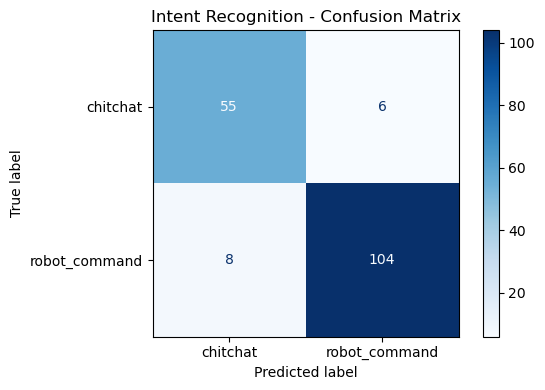

In [8]:
# Save intent recognizer
pickle.dump(intent_recognizer, open(RESOURCE_PATH['INTENT_RECOGNIZER'], 'wb'))
print("Intent recognizer saved!")

# Confusion matrix for intent recognition
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test_i, y_pred_i, labels=['chitchat', 'robot_command'])
disp = ConfusionMatrixDisplay(cm, display_labels=['chitchat', 'robot_command'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Intent Recognition - Confusion Matrix')
plt.tight_layout()
plt.show()

## Part III: Action Category Classification

For robot commands, classify which **action category** it belongs to.

This mirrors the original notebook's programming language tag classification.

Categories: PICK_PLACE, CUT, DRILL, SAND, ASSEMBLE, GLUE, CLAMP, TOOL_ASSIST, NAVIGATE, STATUS, MEASURE

In [9]:
# Prepare data for tag classification (only robot commands)
X_tag = commands_df['text'].values
y_tag = commands_df['tag'].values

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tag, y_tag, test_size=0.2, random_state=0, stratify=y_tag
)

print(f"Tag train size = {len(X_train_t)}, test size = {len(X_test_t)}")

Tag train size = 444, test size = 112


In [10]:
# Reuse the same TF-IDF vectorizer
X_train_tag_tfidf = tfidf_vectorizer.transform(X_train_t)
X_test_tag_tfidf = tfidf_vectorizer.transform(X_test_t)

In [11]:
# Train tag classifier with OneVsRest
# class_weight='balanced' helps categories with fewer distinctive words
tag_classifier = OneVsRestClassifier(
    LogisticRegression(
        solver='lbfgs', penalty='l2', C=5, random_state=0, max_iter=1000,
        class_weight='balanced'
    )
).fit(X_train_tag_tfidf, y_train_t)

# Evaluate
y_pred_t = tag_classifier.predict(X_test_tag_tfidf)
print(f"Tag Classification Accuracy: {accuracy_score(y_test_t, y_pred_t):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t, zero_division=0))

Tag Classification Accuracy: 0.8304

Classification Report:
              precision    recall  f1-score   support

    ASSEMBLE       0.89      0.80      0.84        10
       CLAMP       1.00      1.00      1.00        10
         CUT       0.75      0.60      0.67        10
       DRILL       0.85      1.00      0.92        11
        GLUE       0.82      0.90      0.86        10
     MEASURE       0.64      0.70      0.67        10
    NAVIGATE       0.82      0.90      0.86        10
  PICK_PLACE       0.78      0.70      0.74        10
        SAND       1.00      1.00      1.00        11
      STATUS       0.78      0.70      0.74        10
 TOOL_ASSIST       0.80      0.80      0.80        10

    accuracy                           0.83       112
   macro avg       0.83      0.83      0.83       112
weighted avg       0.83      0.83      0.83       112



Tag classifier saved!


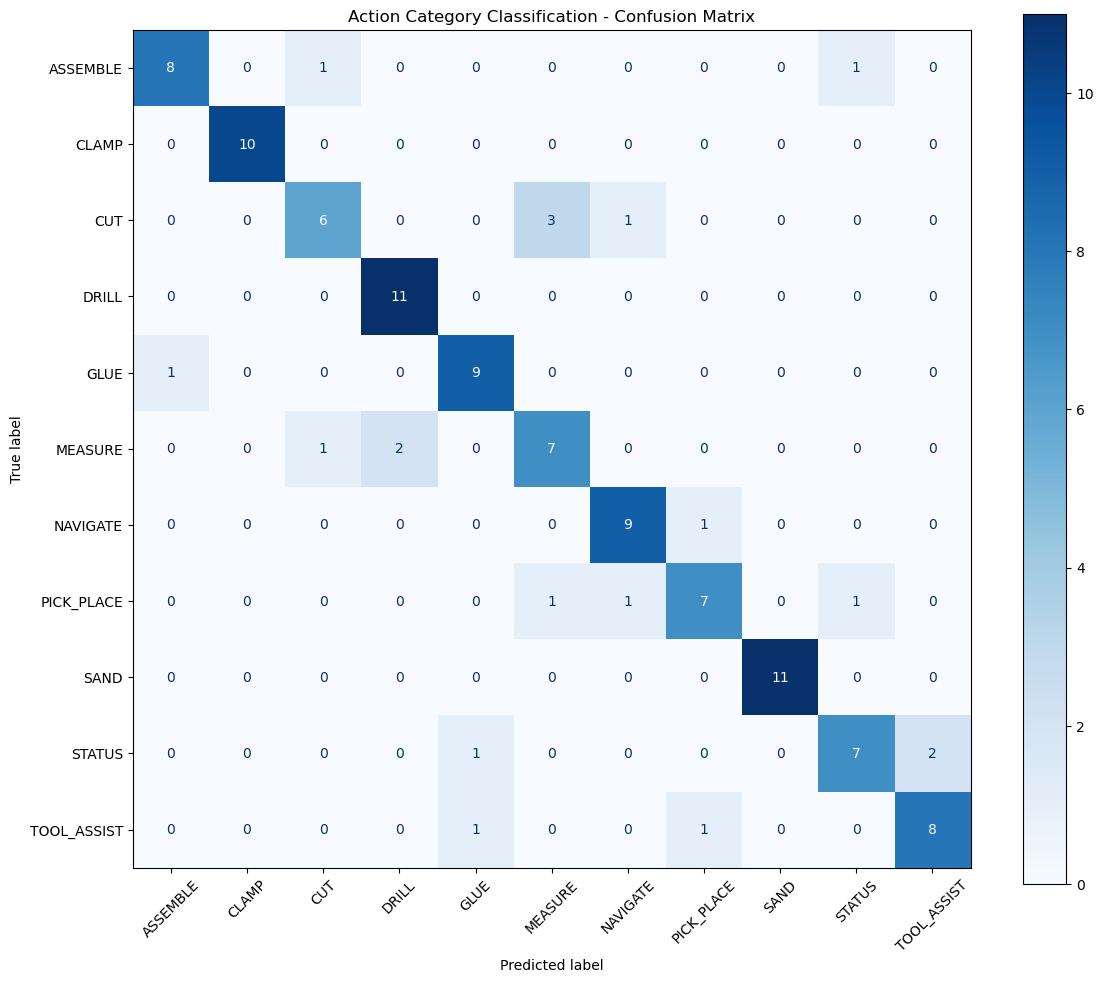

In [12]:
# Save tag classifier
pickle.dump(tag_classifier, open(RESOURCE_PATH['TAG_CLASSIFIER'], 'wb'))
print("Tag classifier saved!")

# Confusion matrix for tag classification
fig, ax = plt.subplots(figsize=(12, 10))
labels = sorted(commands_df['tag'].unique())
cm = confusion_matrix(y_test_t, y_pred_t, labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Action Category Classification - Confusion Matrix')
plt.tight_layout()
plt.show()

## Part IV: Testing the Full Pipeline

Now let's test the complete system with the DialogueManager.

In [13]:
import importlib
import dialogue_manager
importlib.reload(dialogue_manager)

<module 'dialogue_manager' from 'c:\\Users\\User\\Desktop\\Universidade\\2º Semestre\\LNIAGIA\\Demos\\Naive ChatBot\\robot manel\\dialogue_manager.py'>

In [14]:
# Initialize the dialogue manager
dm = dialogue_manager.DialogueManager(RESOURCE_PATH)

Loading resources...
Resources loaded successfully!


In [15]:
# Test with various inputs - including previously failing cases
test_questions = [
    # Chitchat (previously "How are you doing?" and "What can you do?" failed)
    "Hello",
    "How are you doing?",
    "What can you do?",
    "Thank you!",
    "I am tired",
    "tell me a joke",
    "what time is it",
    "nice weather today",
    
    # Robot commands - different phrasings for same task
    "cut this board in half",
    "saw through the plank",           # CUT
    
    "drill a hole in this board",
    "make a hole here",                # DRILL
    
    "sand this surface smooth",
    "smooth out the rough edges",      # SAND
    
    "put the frame together",
    "assemble the shelf unit",         # ASSEMBLE (previously failed)
    
    "glue these two pieces together",
    "apply wood glue to the joint",    # GLUE
    
    "clamp this assembly",
    "hold the pieces together with clamps",  # CLAMP
    
    "pass me the wrench",
    "hand me the screwdriver",         # TOOL_ASSIST
    
    "move to station two",
    "go to the cutting area",          # NAVIGATE
    
    "what is the current status",
    "give me a summary",               # STATUS (previously failed)
    
    "measure this board",
    "check the length of this piece",  # MEASURE
    
    "pick up the screw",
    "grab that component",             # PICK_PLACE
]

# Track results for accuracy summary
correct = 0
total = 0
expected = {
    "Hello": "chitchat", "How are you doing?": "chitchat", 
    "What can you do?": "chitchat", "Thank you!": "chitchat",
    "I am tired": "chitchat", "tell me a joke": "chitchat",
    "what time is it": "chitchat", "nice weather today": "chitchat",
    "cut this board in half": "CUT", "saw through the plank": "CUT",
    "drill a hole in this board": "DRILL", "make a hole here": "DRILL",
    "sand this surface smooth": "SAND", "smooth out the rough edges": "SAND",
    "put the frame together": "ASSEMBLE", "assemble the shelf unit": "ASSEMBLE",
    "glue these two pieces together": "GLUE", "apply wood glue to the joint": "GLUE",
    "clamp this assembly": "CLAMP", "hold the pieces together with clamps": "CLAMP",
    "pass me the wrench": "TOOL_ASSIST", "hand me the screwdriver": "TOOL_ASSIST",
    "move to station two": "NAVIGATE", "go to the cutting area": "NAVIGATE",
    "what is the current status": "STATUS", "give me a summary": "STATUS",
    "measure this board": "MEASURE", "check the length of this piece": "MEASURE",
    "pick up the screw": "PICK_PLACE", "grab that component": "PICK_PLACE",
}

for q in test_questions:
    answer = dm.generate_answer(q)
    print(f"Q: {q}")
    print(f"A: {answer}")
    
    # Check if the answer matches expected intent/tag
    exp = expected[q]
    if exp == "chitchat":
        is_correct = "Action:" not in str(answer) and "not confident" not in str(answer)
    else:
        is_correct = f"Action: {exp}" in str(answer)
    
    total += 1
    if is_correct:
        correct += 1
    else:
        print(f"   *** WRONG (expected {exp}) ***")
    print()

print(f"\n{'='*50}")
print(f"End-to-end test accuracy: {correct}/{total} = {correct/total:.1%}")
print(f"{'='*50}")

Q: Hello
A: Hello! I'm Manel, your carpentry assistant. How can I help?

Q: How are you doing?
A: Good day! What task shall we do?

Q: What can you do?
A: Hello! I'm Manel, your carpentry assistant. How can I help?

Q: Thank you!
A: Hello! I'm Manel, your carpentry assistant. How can I help?

Q: I am tired
A: I wish I could help with that! But I'm better with wood. Need anything cut or drilled?

Q: tell me a joke
A: Ha, I'm just a robot - I stick to carpentry! What do you need me to do?

Q: what time is it
A: Ha, I'm just a robot - I stick to carpentry! What do you need me to do?

Q: nice weather today
A: That's above my pay grade! But I can sand, cut, drill, or assemble something for you.

Q: cut this board in half
A: Action: CUT - Cut, saw, or trim a piece of wood
Confidence: 0.55
Steps: verify_workpiece_clamped -> select_cutting_tool -> measure_cut_position -> align_cutting_tool -> activate_dust_extraction -> execute_cut -> deactivate_tool -> verify_cut_quality -> remove_offcut
Safe

In [16]:
# Show task summary
print(dm.get_summary())

=== Task Summary ===
1. [11:12:42] CUT (confidence=0.55) - "cut this board in half"
2. [11:12:42] CUT (confidence=0.46) - "saw through the plank"
3. [11:12:42] DRILL (confidence=0.58) - "drill a hole in this board"
4. [11:12:42] DRILL (confidence=0.64) - "make a hole here"
5. [11:12:42] SAND (confidence=0.65) - "sand this surface smooth"
6. [11:12:42] SAND (confidence=0.63) - "smooth out the rough edges"
7. [11:12:42] ASSEMBLE (confidence=0.45) - "put the frame together"
8. [11:12:42] ASSEMBLE (confidence=0.51) - "assemble the shelf unit"
9. [11:12:42] GLUE (confidence=0.49) - "glue these two pieces together"
10. [11:12:42] GLUE (confidence=0.63) - "apply wood glue to the joint"
11. [11:12:42] CLAMP (confidence=0.56) - "clamp this assembly"
12. [11:12:42] CLAMP (confidence=0.53) - "hold the pieces together with clamps"
13. [11:12:42] TOOL_ASSIST (confidence=0.58) - "pass me the wrench"
14. [11:12:42] TOOL_ASSIST (confidence=0.57) - "hand me the screwdriver"
15. [11:12:42] NAVIGATE (con

## Part V: Interactive Chat Loop

Run this cell to chat with Robot Manel interactively.
Type `quit` or `exit` to stop. Type `summary` to see task history.

In [ ]:
print("=" * 50)
print("Robot Manel - Carpentry Assistant")
print("Type 'quit' to exit, 'summary' for task history")
print("=" * 50)

while True:
    text = input("\nYou: ").strip()
    if not text:
        continue
    if text.lower() in {'quit', 'exit'}:
        print("\nGoodbye! Final summary:")
        print(dm.get_summary())
        break
    if text.lower() in {'summary', 'summarize', 'report'}:
        print(f"\n{dm.get_summary()}")
        continue
    
    answer = dm.generate_answer(text)
    print(f"Manel: {answer}")

Robot Manel - Carpentry Assistant
Type 'quit' to exit, 'summary' for task history
Manel: Good day! What task shall we do?
Manel: Hi there! Ready to work. What do you need?
Manel: I wish I could help with that! But I'm better with wood. Need anything cut or drilled?
Manel: Hello! I'm Manel, your carpentry assistant. How can I help?
Manel: Action: SAND - Sand or smooth a wood surface
Confidence: 0.65
Steps: verify_workpiece_secured -> select_sandpaper_grit -> attach_sandpaper_to_sander -> activate_dust_extraction -> sand_surface_with_grain -> check_surface_smoothness -> change_grit_if_needed -> final_pass -> deactivate_sander -> clean_dust
Safety: Always sand with the grain. Start coarse, finish fine.
Manel: Action: PICK_PLACE - Pick up, move, or place an object
Confidence: 0.51
Steps: identify_target_object -> plan_approach_trajectory -> open_gripper -> approach_object -> close_gripper -> lift_object -> transport_to_destination -> place_object -> open_gripper -> retract_arm
Safety: Veri